# Notebook 4: Case Studies
**Paper 5 – Cross-Framework Quantum Algorithm Benchmarking**

**Purpose**: In-depth analysis of the two primary case studies:
- **Case Study 1**: Bell State — simplest circuit, distribution equivalence baseline
- **Case Study 2**: Grover's Algorithm — highest gate-count divergence, diffusion operator decomposition

**Prerequisites**: Notebooks 1–3 must be run first.

**Pipeline step**: Step 4 of 5

In [8]:
import os, sys, json
import importlib
QCANVAS_ROOT = os.path.abspath('../..')
if QCANVAS_ROOT not in sys.path:
    sys.path.insert(0, QCANVAS_ROOT)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import benchmarks.scripts.figure_styles as figure_styles
importlib.reload(figure_styles)
from benchmarks.scripts.figure_styles import (
    apply_paper_style, save_figure, plot_measurement_histogram,
    plot_scaling_lines, FRAMEWORK_COLORS, FRAMEWORK_LABELS
)
from benchmarks.scripts.statistical_tests import pairwise_jsd, js_divergence

## Case Study 1: Bell State

The Bell state is the **simplest non-trivial 2-qubit circuit**: H + CNOT + measure.
It serves as the distribution equivalence **baseline** — all three frameworks should
produce identical output (JSD ≈ 0). Any divergence indicates a framework-specific
compilation artefact.

In [9]:
# Load Bell State QASM files and show structural comparison
QASM_DIR = '../qasm_outputs'
bell_qasms = {}
for fw in ['qiskit', 'cirq', 'pennylane']:
    path = os.path.join(QASM_DIR, f'bell_state_2q_{fw}.qasm')
    if os.path.exists(path):
        with open(path) as f:
            bell_qasms[fw] = f.read()
        print(f'\n=== Bell State — {FRAMEWORK_LABELS[fw]} QASM ===')
        print(bell_qasms[fw])
    else:
        print(f'[MISSING] {path}')


=== Bell State — Qiskit QASM ===
OPENQASM 3.0;
include "stdgates.inc";

// Mathematical constants
const float pi = 3.141592653589793;
const float e = 2.718281828459045;
const float pi_2 = 1.5707963267948966;
const float pi_4 = 0.7853981633974483;
const float tau = 6.283185307179586;
const float sqrt2 = 1.4142135623730951;
const float sqrt1_2 = 0.7071067811865476;


// Quantum and classical registers
qubit[2] q;
bit[2] c;

// Circuit operations
h q[0];
cx q[0], q[1];
c[0] = measure q[0];
c[1] = measure q[1];

=== Bell State — Cirq QASM ===
OPENQASM 3.0;
include "stdgates.inc";

// Mathematical constants
const float pi = 3.141592653589793;
const float e = 2.718281828459045;
const float pi_2 = 1.5707963267948966;
const float pi_4 = 0.7853981633974483;
const float tau = 6.283185307179586;
const float sqrt2 = 1.4142135623730951;
const float sqrt1_2 = 0.7071067811865476;


// Quantum and classical registers
qubit[2] q;
bit[2] c;

// Circuit operations
h q[0];
cx q[0], q[1];
c[0] = measure q

In [10]:
# Load Bell State measurement distributions (4096 shots, trial 1)
DIST_DIR = '../metrics/distributions'
bell_dists = {}
for fw in ['qiskit', 'cirq', 'pennylane']:
    path = os.path.join(DIST_DIR, f'bell_state_2q_{fw}_4096_trial1.json')
    if os.path.exists(path):
        with open(path) as f:
            bell_dists[fw] = json.load(f)

if bell_dists:
    pairs = pairwise_jsd(bell_dists)
    print('Bell State pairwise JSD:')
    for pair, result in pairs.items():
        print(f'  {pair}: JSD={result["jsd"]:.5f}  {result["label"]}')
else:
    print('[SKIP] Distribution files not found — run simulate_all.py first')

Bell State pairwise JSD:
  qiskit_vs_cirq: JSD=0.00290  ✓
  qiskit_vs_pennylane: JSD=0.00664  ✓
  cirq_vs_pennylane: JSD=0.00373  ✓


[save_figure] Saved: fig13_bell_state_distribution.pdf / .png → c:\Study Material\FYP\QCanvas-Project\QCanvas\benchmarks\results\simulation/


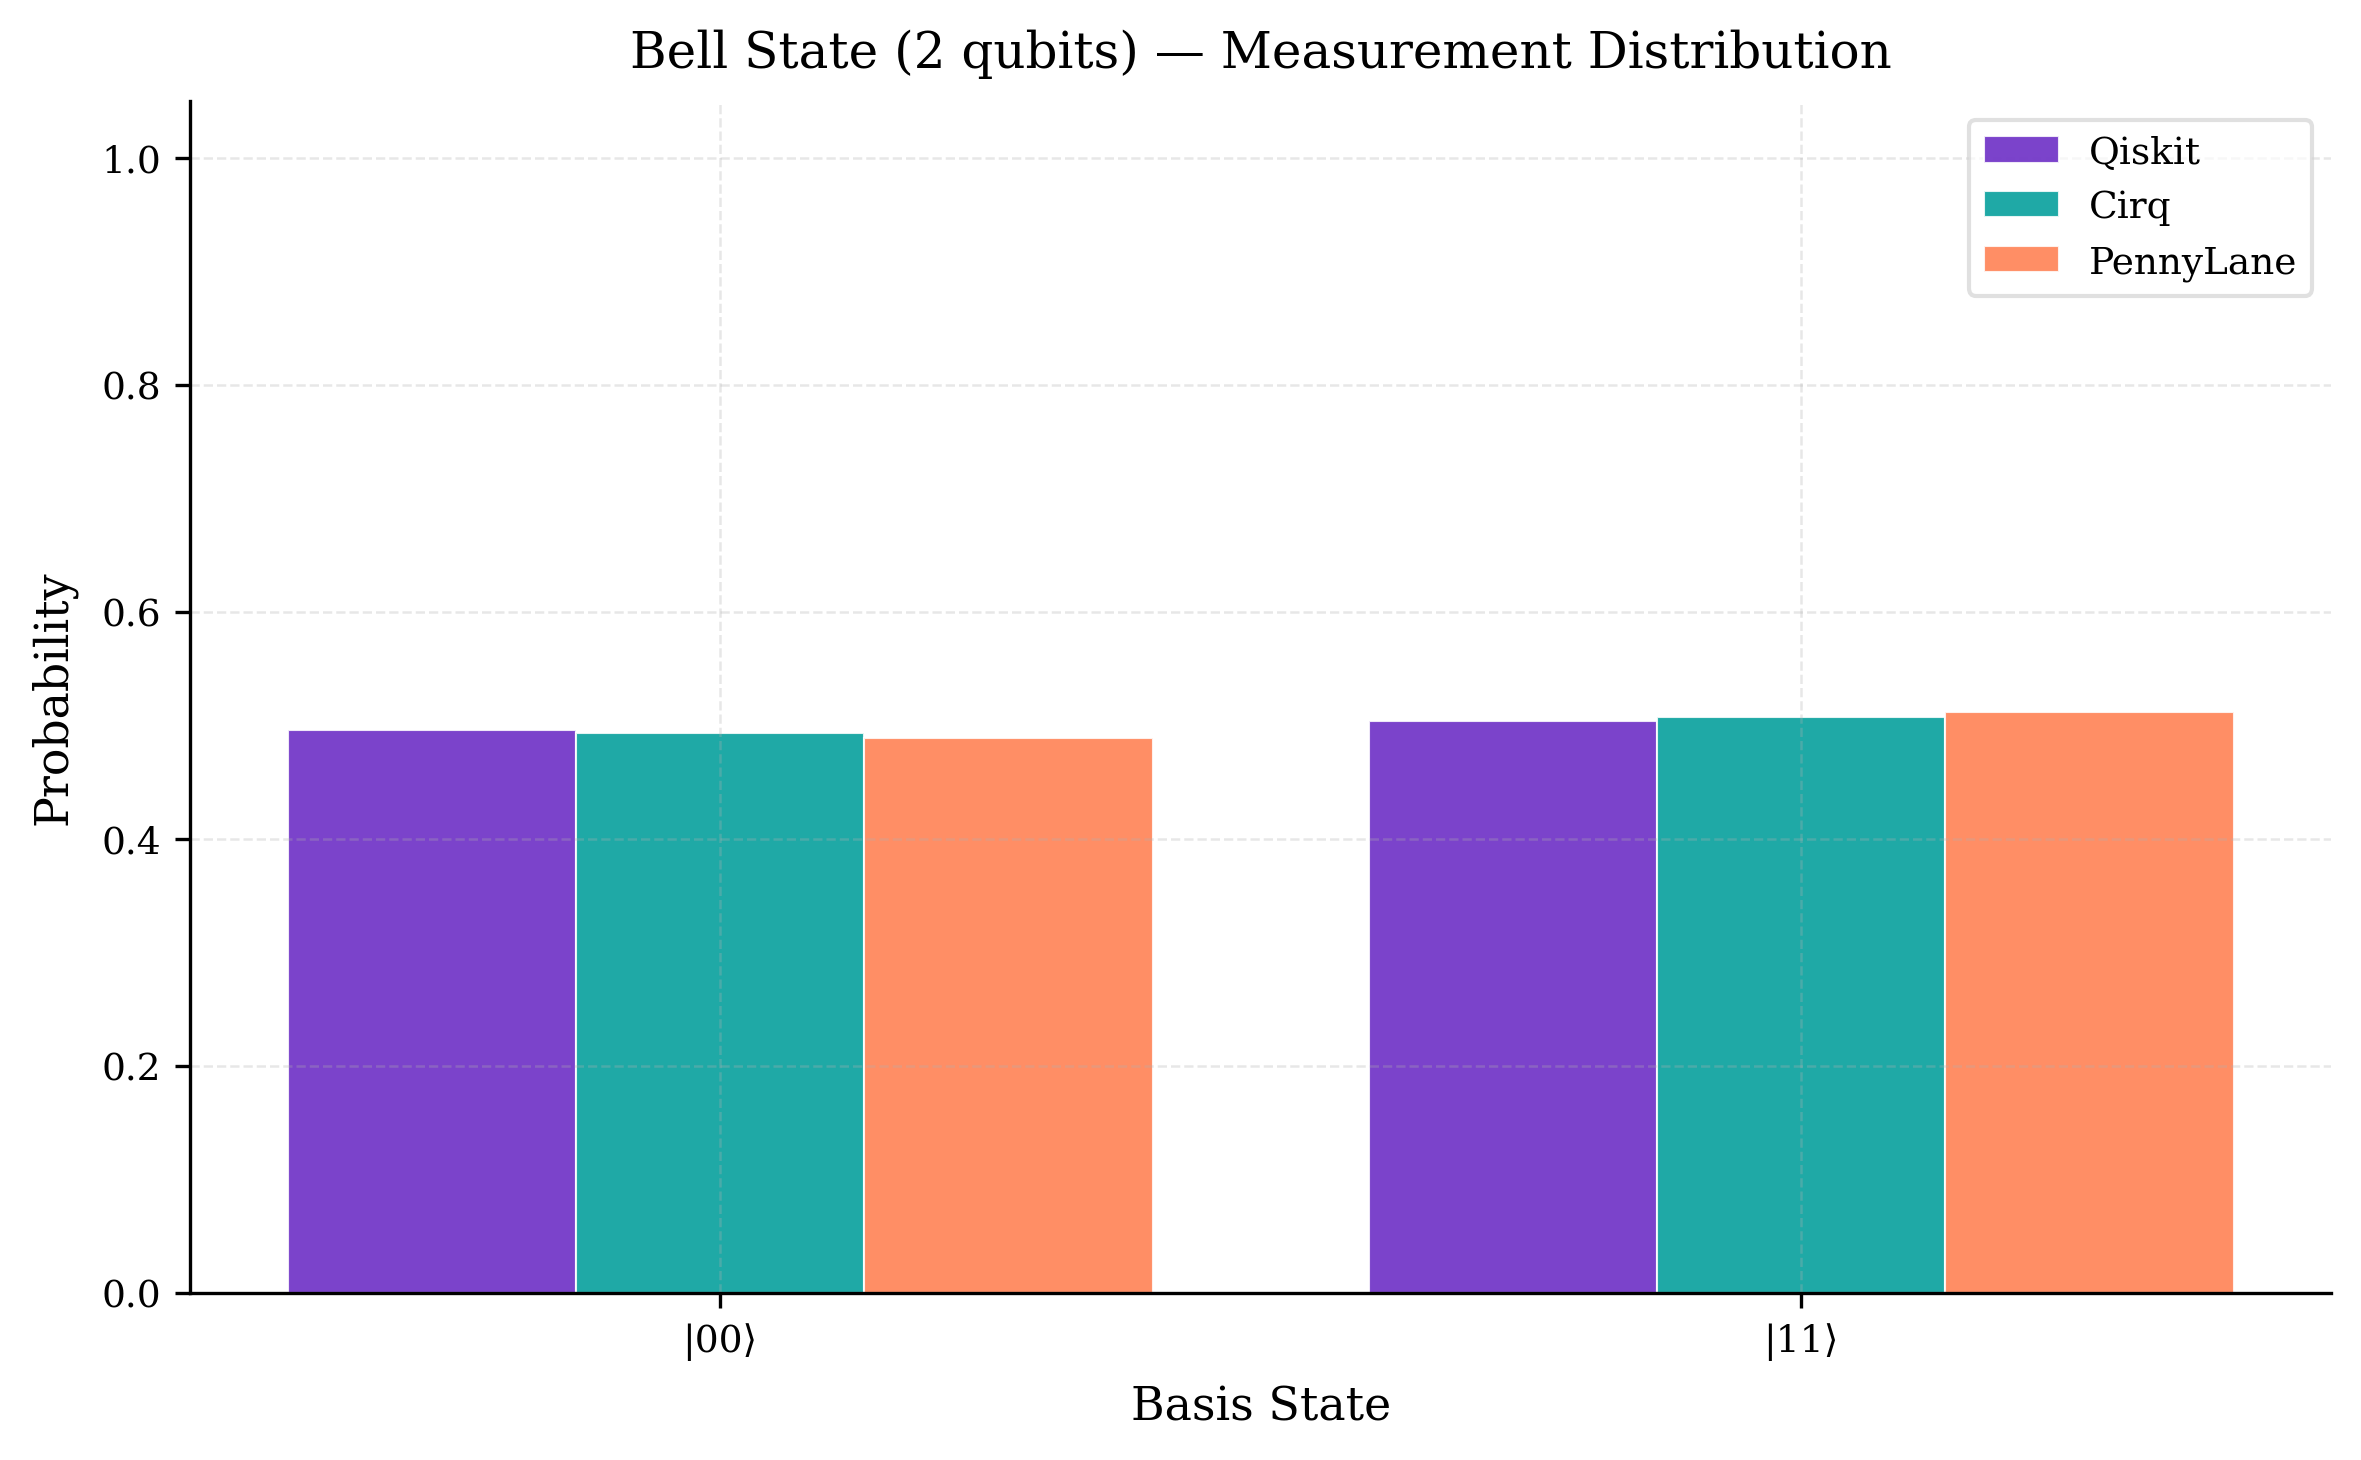

In [11]:
# ── Fig. 13: Bell State measurement histograms ───────────────────────────────
if bell_dists:
    apply_paper_style()
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_measurement_histogram(ax, bell_dists, 'Bell State', n_qubits=2)
    plt.tight_layout()
    save_figure(fig, 'fig13_bell_state_distribution', 'simulation')
    plt.show()

## Case Study 2: Grover's Algorithm

Grover's algorithm is the **primary divergence case study**. The oracle and diffusion
operator both require multi-controlled-Z gates, which each framework decomposes
differently:
- **Qiskit**: `mcx(controls, target)` → Toffoli chain decomposition
- **Cirq**: `ControlledGate(X, num_controls=k)` → different ancilla usage
- **PennyLane**: `qml.GroverOperator` template → optimised but opaque decomposition

This produces measurable gate count and depth differences (RQ1, RQ4).

In [12]:
# Grover's gate count scaling across frameworks
df_struct = pd.read_csv('../metrics/structural_metrics.csv')
df_grover = df_struct[df_struct['algorithm'] == 'grovers_algorithm']

print('Grover gate count by qubit count and framework:')
pivot = df_grover.pivot_table(index='n_qubits', columns='framework', values='total_gates')
print(pivot.to_string())

print('\nGrover circuit depth by qubit count and framework:')
pivot_d = df_grover.pivot_table(index='n_qubits', columns='framework', values='circuit_depth')
print(pivot_d.to_string())

Grover gate count by qubit count and framework:
framework  cirq  pennylane  qiskit
n_qubits                          
2          18.0       18.0    18.0
3          18.0       46.0    18.0
4          18.0       80.0    18.0
5          18.0      130.0    18.0
6          18.0      216.0    18.0

Grover circuit depth by qubit count and framework:
framework  cirq  pennylane  qiskit
n_qubits                          
2          12.0       12.0    12.0
3          12.0       22.0    12.0
4          12.0       32.0    12.0
5          12.0       50.0    12.0
6          12.0       62.0    12.0


[save_figure] Saved: fig14_grovers_scaling.pdf / .png → c:\Study Material\FYP\QCanvas-Project\QCanvas\benchmarks\results\structural/


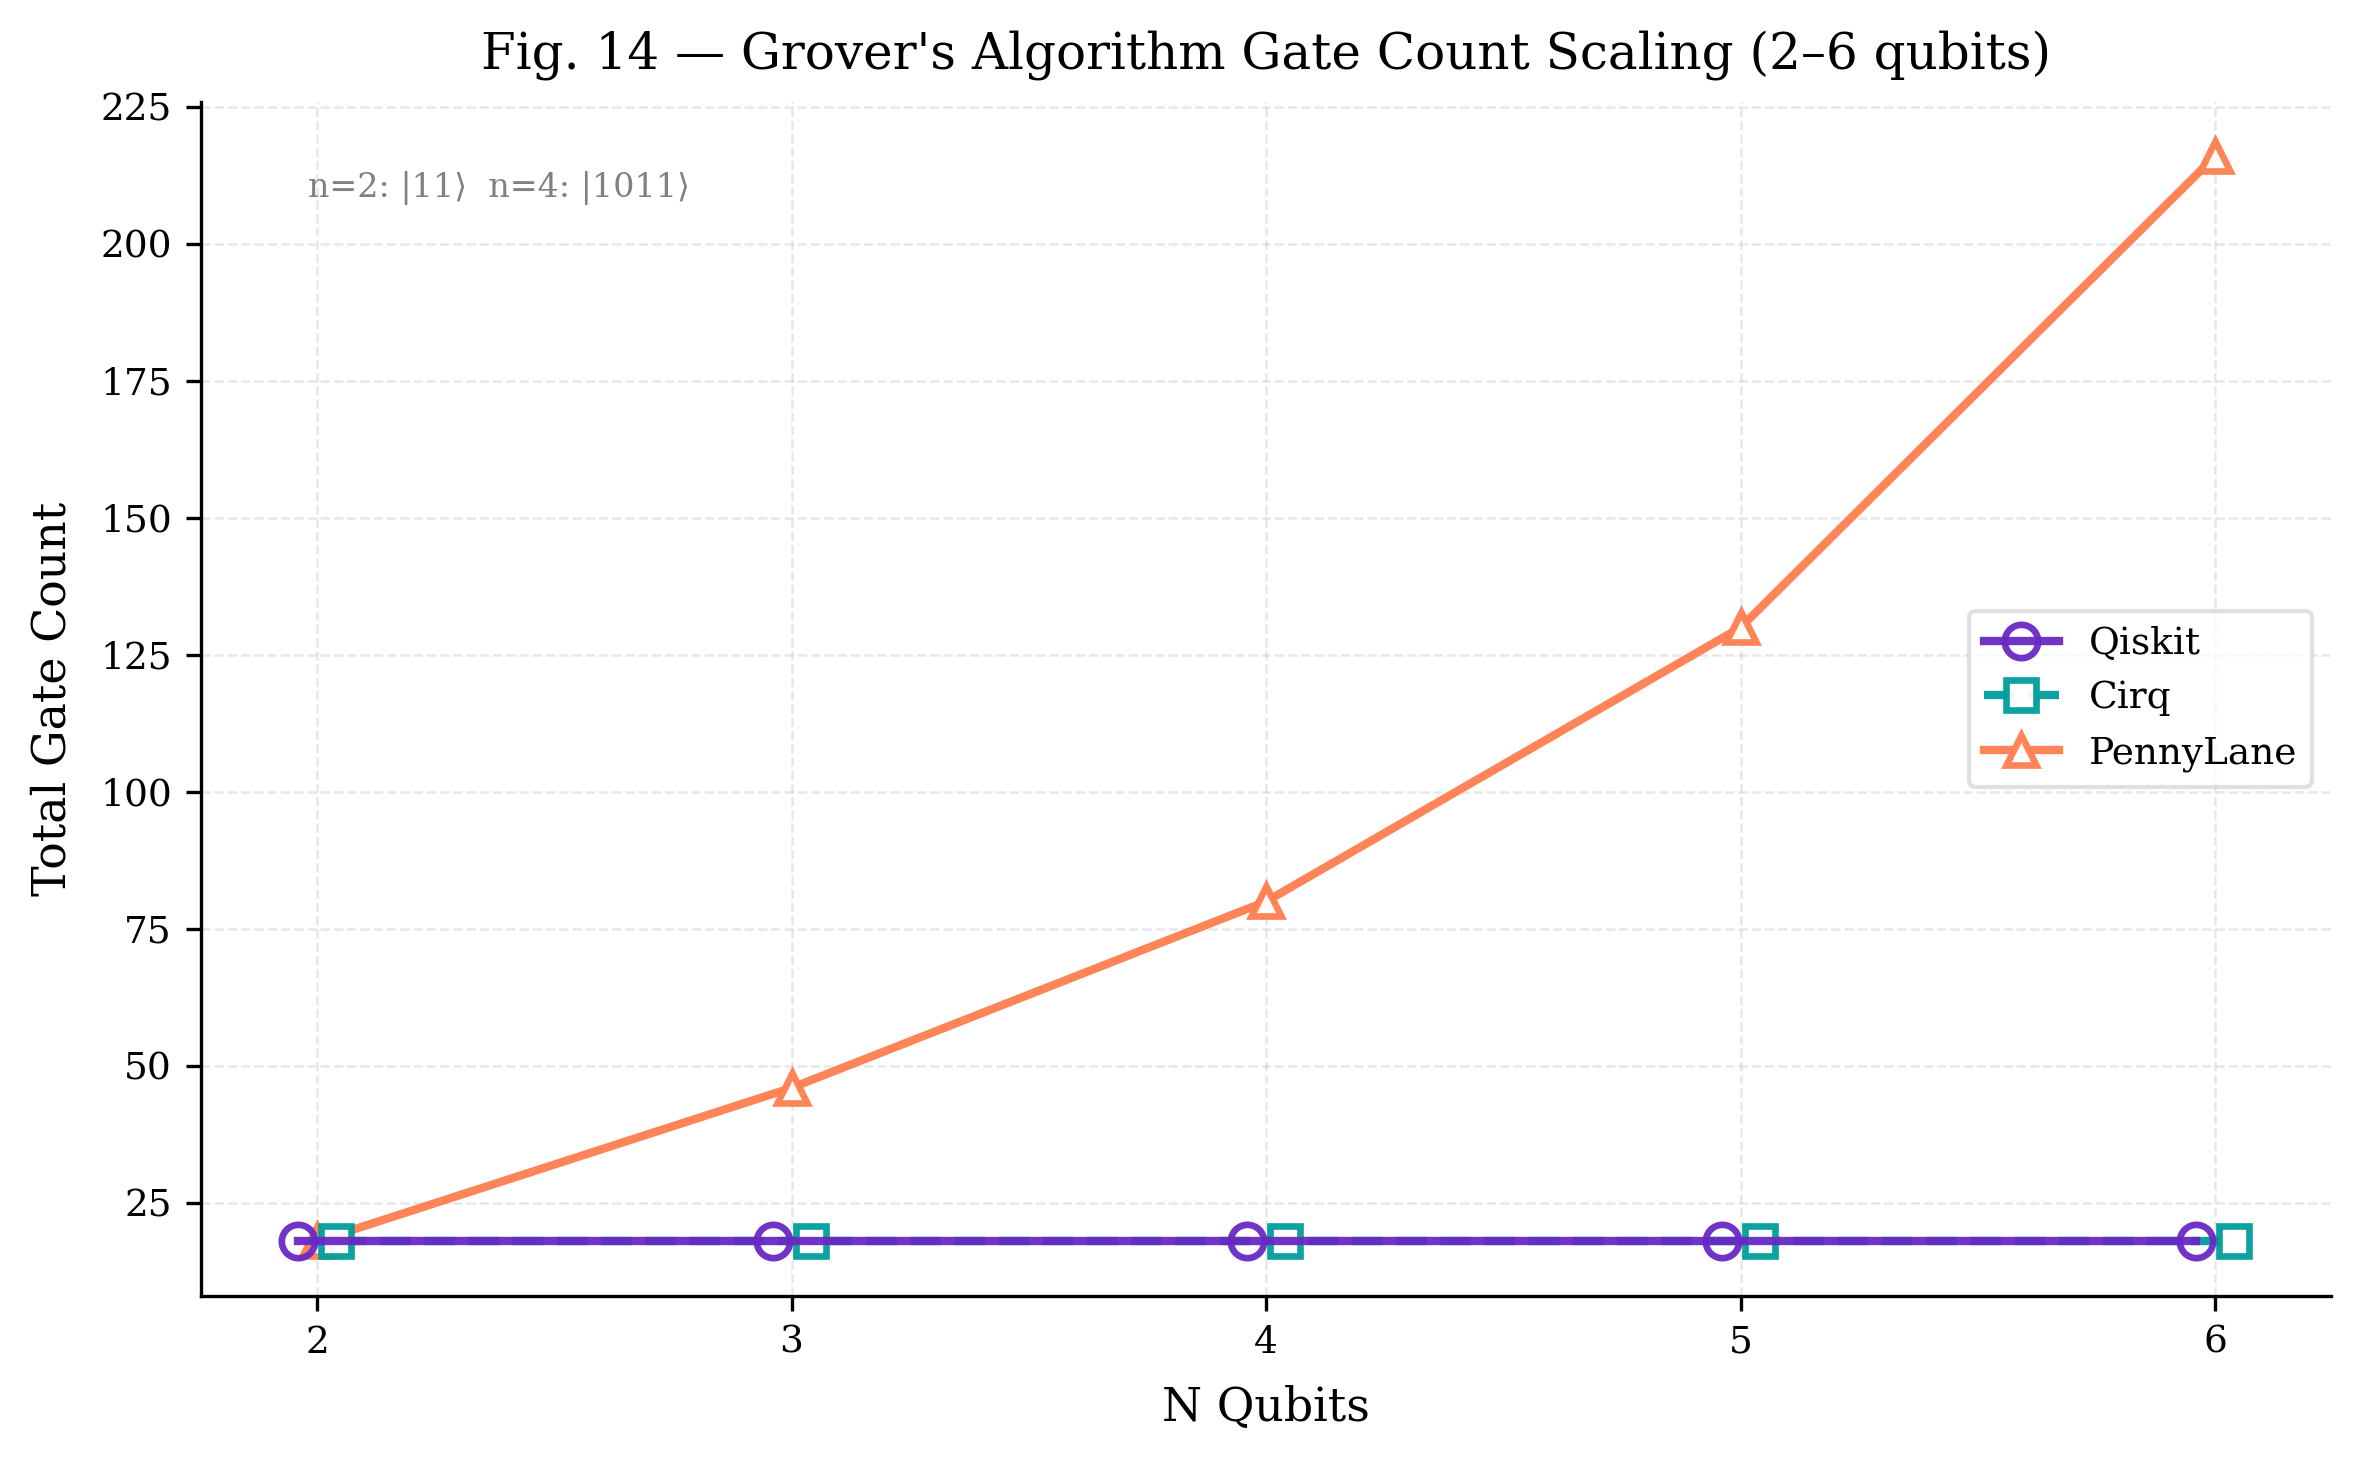

In [13]:
# ── Fig. 14: Grover's gate count scaling ─────────────────────────────────────
apply_paper_style()
fig, ax = plt.subplots(figsize=(8, 5))
plot_scaling_lines(
    ax, df_grover,
    x_col='n_qubits', y_col='total_gates',
    title="Fig. 14 — Grover's Algorithm Gate Count Scaling (2–6 qubits)",
    ylabel='Total Gate Count',
)
# Annotate the marked states
ax.annotate('n=2: |11⟩  n=4: |1011⟩', xy=(0.05, 0.92),
            xycoords='axes fraction', fontsize=8, color='grey')
plt.tight_layout()
save_figure(fig, 'fig14_grovers_scaling', 'structural')
plt.show()

In [14]:
# Gate count difference at n=4 (Key finding for paper)
grover_4q = df_grover[df_grover['n_qubits'] == 4]
if not grover_4q.empty:
    counts = grover_4q.set_index('framework')['total_gates']
    print('Gate count at n=4 qubits:')
    for fw in ['qiskit', 'cirq', 'pennylane']:
        if fw in counts:
            print(f'  {FRAMEWORK_LABELS[fw]:12s}: {counts[fw]} gates')
    if len(counts) >= 2:
        max_diff = counts.max() - counts.min()
        pct_diff = max_diff / counts.min() * 100
        print(f'\n  Max gate-count divergence: {max_diff:.0f} gates ({pct_diff:.1f}%)')
        print('  → Primary source: multi-controlled-Z decomposition strategy')

Gate count at n=4 qubits:
  Qiskit      : 18 gates
  Cirq        : 18 gates
  PennyLane   : 80 gates

  Max gate-count divergence: 62 gates (344.4%)
  → Primary source: multi-controlled-Z decomposition strategy
